# **Explanatory Data Analysis (EDA) - Health Cost Optimization Strategies (HealthWise)**
*   **Name:** Luis Esteban Torres Perdomo

---


# 1.Bussiness Context

HealthWise, our customer, is a private medical clinic that focuses on providing personalized and efficient medical care, optimizing cost and resources in order to improve the quality of service to its clients.
Currently, HealthWise faces a serious financial situation due to a lack of efficient cost management and little awareness regarding the quality of its services. Lack of appropriate knowledge of operating cost and low control of efficiency in medical services has led to inefficient utilization of the budget with increasing financial loss and lack of long-term viability.

HealthWise does not have an evidence-based strategy in terms of how it can utilize its resources to the fullest, avoid wasteful spending and improve the quality of care it provides to its patients. This exploratory research seeks to produce meaningful information that can help HealthWise make effective strategic choices, reduce running costs, improve efficiency in the delivery of services, and make the healthcare organization financially sustainable.


---


# 2.Objetive
The objective of this project is to identify meaningful trends in medical spending and hospital resource use to allow HealthWise to make sound strategic decisions. By exploratory data analysis, we seek to identify drivers of healthcare spending, segment patients based on their medical spending, and diagnose areas where resources can be optimized. By means of this study, HealthWise will be able to design better policies, reduce wasteful expenditure and improve the quality of service without compromising the financial viability of the health center.



---


# 3. Business questions and analysis approach
1. How does the total cost of medical care vary by age group and gender, and what strategic implications can these differences have for HealthWise?
2. Which treatments or medical conditions, in the age group scoring highest in question 1, are costing the most? And how can HealthWise best manage these high-cost pediatric cases?
3. What are the diseases that generate the highest hospital demand in HealthWise, what is their specific impact on costs?
4. What are the variations in medical costs according to the hospital providing the service and how could HealthWise use this data to refine its business operations?
5. Which medical conditions have the greatest variability in costs and how can HealthWise standardize their management?
6.

---
# 4.Theoretical framework
Management of hospital expenses effectively is required to achieve the economic sustainability of healthcare organizations. Various researches have revealed that hospital stay, type of disease to be treated and specific medical interventions may significantly influence operating costs (Kaplan and Porter, 2011; Porter and Teisberg, 2006). Therefore, conducting a detailed exploratory analysis makes it easy to identify self-evident areas where efficiency can be increased, unnecessary expenses reduced and usage of medical and administrative resources optimized.

---

# 5. Data Source

The datas set is the public sources of Kaggle.com and the link of datasource is : https://www.kaggle.com/datasets/prasad22/healthcare-dataset



---

# 6. Data Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df = pd.read_csv("/content/healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [ ]:
print(df.describe())

                Age  Billing Amount   Room Number
count  55500.000000    55500.000000  55500.000000
mean      51.539459    25539.316097    301.134829
std       19.602454    14211.454431    115.243069
min       13.000000    -2008.492140    101.000000
25%       35.000000    13241.224652    202.000000
50%       52.000000    25538.069376    302.000000
75%       68.000000    37820.508436    401.000000
max       89.000000    52764.276736    500.000000



The data set consists of 55,500 records and 15 columns and **no null values**, yet the following columns were inconsistent:
- Date of Admission and Discharge Date were in text format instead of 'datetime', hence hospitalization calculations are not easy.
- Hospital and doctors names may have variations that generate duplicates.
- Negative costs that do not make financial sense and need correction.
- Hospitalization dates should be verified to avoid inconsistencies.


## Cleaning and preprocessing
-normalize columns to facilitate their call during programming

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

- Dates were transformed into 'datetime' for the convenience of hospitalization calculations.

In [ ]:
df["date_of_admission"] = pd.to_datetime(df["date_of_admission"], errors="coerce")
df["discharge_date"] = pd.to_datetime(df["discharge_date"], errors="coerce")

- Change the variable type from room number to 'object' because no mathematical operations are to be performed with this variable

In [ ]:
df['room_number'] = df['room_number'].astype(object)

- Column 'hospital_stay_days' has been added to measure hospital stay duration.

In [ ]:
df["hospital_stay_days"] = (df["discharge_date"] - df["date_of_admission"]).dt.days

- Delete records with missing or invalid dates

In [ ]:
df.dropna(subset=["date_of_admission", "discharge_date"], inplace=True)

- Eliminate negative values in billing_amount because there cannot be invoices with negative values, so they are erroneous records.

In [ ]:
df["billing_amount"] = pd.to_numeric(df["billing_amount"], errors="coerce")
df = df[df["billing_amount"] > 0]

Ages are grouped into ranges for a better visualization of the data.

In [ ]:
age_bins = [0, 18, 30, 45, 60, 75, 90, 120]
age_labels = ["0-18", "19-30", "31-45", "46-60", "61-75", "76-90", "91+"]
df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels, right=False)


<ipython-input-242-ebf39e901dbe>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels, right=False)


-It was found that some variable names are the same but in different order, so it is unified to avoid duplicates in the analysis and improve accuracy when grouping data.
-Unify hospital, doctor and medical_condition names to avoid duplicates by word order.

In [ ]:
df["hospital"] = df["hospital"].apply(lambda x: " ".join(sorted(x.split())))
df["doctor"] = df["doctor"].apply(lambda x: " ".join(sorted(x.split())))
df["medical_condition"] = df["medical_condition"].apply(lambda x: " ".join(sorted(x.split())))

<ipython-input-243-1ea67ecea033>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["hospital"] = df["hospital"].apply(lambda x: " ".join(sorted(x.split())))


In [ ]:
df.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results,hospital_stay_days,age_group
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Miller Sons and,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2,31-45
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Davies Samantha,Inc Kim,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,61-75
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Mitchell Tiffany,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15,76-90
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers Vang, and",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30,19-30
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Hanna Kathleen,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20,31-45


In [ ]:
print(df.info())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
Index: 55392 entries, 0 to 55499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   name                55392 non-null  object        
 1   age                 55392 non-null  int64         
 2   gender              55392 non-null  object        
 3   blood_type          55392 non-null  object        
 4   medical_condition   55392 non-null  object        
 5   date_of_admission   55392 non-null  datetime64[ns]
 6   doctor              55392 non-null  object        
 7   hospital            55392 non-null  object        
 8   insurance_provider  55392 non-null  object        
 9   billing_amount      55392 non-null  float64       
 10  room_number         55392 non-null  object        
 11  admission_type      55392 non-null  object        
 12  discharge_date      55392 non-null  datetime64[ns]
 13  medication          55392 non-null  object        




---
# 8. Exploratory Data Analysis
## 8.1 How does the total cost of medical care vary by age group and gender, and what strategic implications can these differences have for HealthWise?



In [ ]:
median_pivot = df.groupby(["age_group", "gender"] , observed=False)["billing_amount"].median().unstack()
print(f'Median:\n', median_pivot)

Median:
 gender           Female          Male
age_group                            
0-18       30871.424545  28752.660519
19-30      25614.136325  25140.469302
31-45      24744.149545  26073.807219
46-60      26033.294338  25494.813249
61-75      25363.049220  25840.120403
76-90      25421.975365  25725.266587
91+                 NaN           NaN


Text(0, 0.5, 'Average Billing Amount')

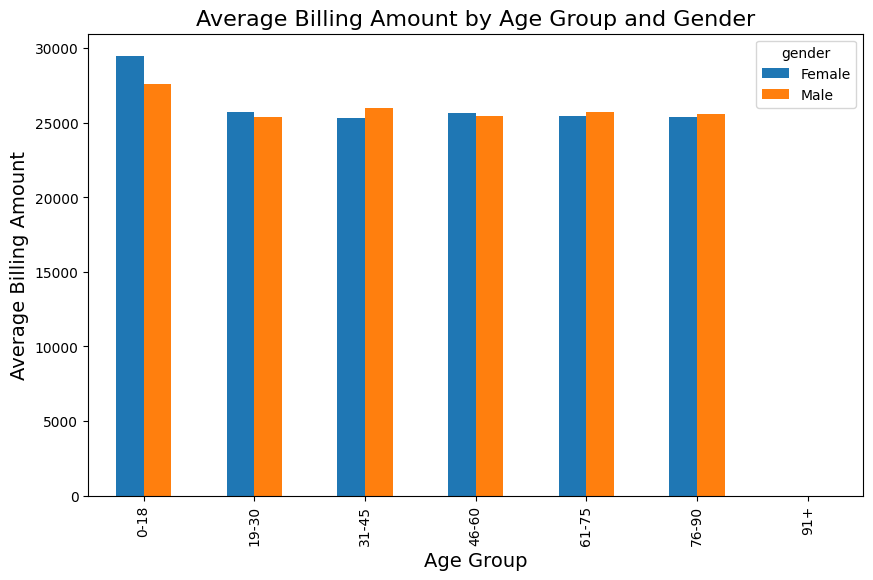

In [ ]:
pivot = df.groupby(["age_group", "gender"],observed=False)["billing_amount"].mean().unstack()
pivot.plot(kind='bar', figsize=(10, 6))
plt.title("Average Billing Amount by Age Group and Gender", fontsize=16)
plt.xlabel("Age Group", fontsize=14)
plt.ylabel("Average Billing Amount", fontsize=14)

**Analysis:**
- Contrary to expectations, the 0-18 age group has the highest median and mean expenditure, which could be due to intensive or specialized pediatric care.
- The median of the group is also high, justifying that these are not outliers.
-The difference in values between genders is not significant

**Recommendations:**
- Review the usual treatments in the 0-18 years group: find out if there are costly diseases or procedures that could be optimized.
- Develop clinical and financial planning schemes based on highly complex child care.



## 8.2 Which treatments or medical conditions, in the age group scoring highest in question 1, are costing the most? And how can HealthWise best manage these high-cost pediatric cases?

In [ ]:
pediatric_df = df[df["age_group"] == "0-18"]
high_cost_conditions = pediatric_df.groupby("medical_condition")["billing_amount"].mean().sort_values(ascending=False).head(10)
summary_stats = pediatric_df[pediatric_df["medical_condition"].isin(high_cost_conditions.index)][["medical_condition", "billing_amount"]]
summary_stats.groupby("medical_condition").agg(['count', 'mean', 'median', 'std', 'min', 'max']).sort_values(('billing_amount', 'mean'), ascending=False)

billing_amount                                            \
                           count          mean        median           std   
medical_condition                                                            
Asthma                        20  31942.692105  34738.510032  14229.121075   
Hypertension                  11  31012.733303  33323.193414  14644.828705   
Arthritis                     21  28881.384092  32923.077365  14600.888112   
Cancer                        21  28454.321677  28752.660519  13944.439784   
Diabetes                      16  28104.699286  27748.599886  12033.371638   
Obesity                       27  24954.567766  25629.940194  13893.524040   

                                               
                            min           max  
medical_condition                              
Asthma              4027.803198  50526.712855  
Hypertension        2635.009310  47320.760586  
Arthritis           1539.611297  49938.603591  
Cancer              6155.254562  48805.454353  
Diabetes           10537.313730  49029.885733  
Obesity             2753.161728  47986.839246

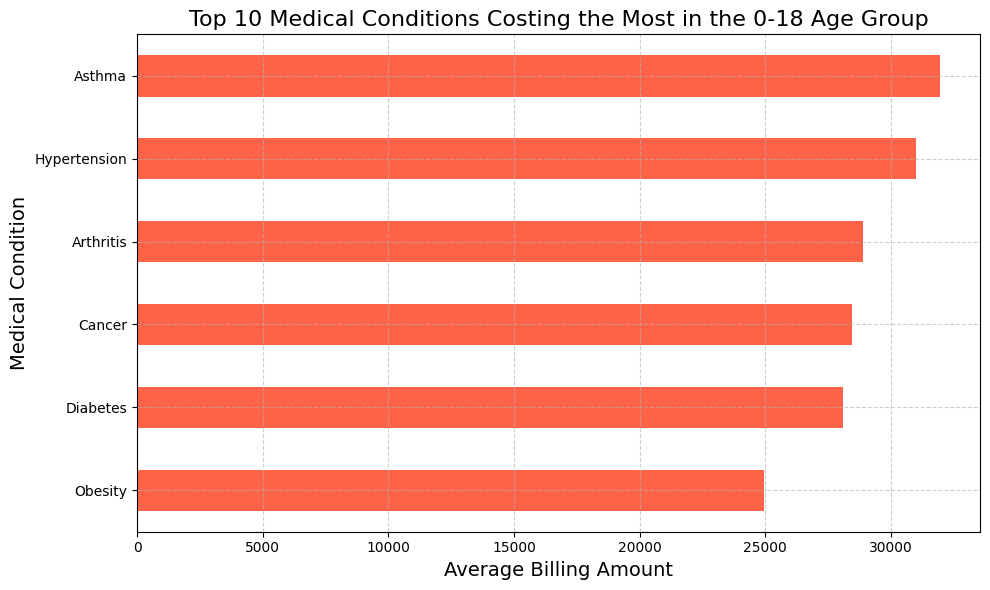

In [ ]:
plt.figure(figsize=(10, 6))
high_cost_conditions.plot(kind='barh', color='tomato')
plt.title("Top 10 Medical Conditions Costing the Most in the 0-18 Age Group", fontsize=16)
plt.xlabel("Average Billing Amount", fontsize=14)
plt.ylabel("Medical Condition", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Analisys:**
- The most prevalent two conditions of this age group are **hypertension** and **asthma**, which suggest that in addition to extremely complex treatment, there also lie widespread chronic diseases with a chronic sapping of the system.
- Although their average costs are not in the top ranks of expense, the **caseload** places a **sustained economic drain** on HealthWise resources.
- This population is a significant economic drain because of not only its unit cost, but also its recurrence in the pediatric population.

**Conclusion**

While illnesses such as cancer or other orphan diseases generate the largest billing averages, even pediatric patients' sheer numbers with common diseases such as asthma or hypertension are economically significant. HealthWise needs to consider both frequency and severity when formulating cost containment plans.

**Recommendations:**
- Fund early prevention and education programs to avoid costly hospitalization in this compromised patient population.
- Offer regular outpatient follow-up to prevent recurrences or unplanned hospitalization.
- Use predictive models for the detection of high-risk pediatric patients.

## 8.3 What are the diseases that generate the highest hospital demand in HealthWise, what is their specific impact on costs?

In [ ]:
condition_summary = df.groupby("medical_condition")["billing_amount"].agg(["count", "mean", "sum"]).sort_values(by="count", ascending=False).head(10)
condition_stats = df[df["medical_condition"].isin(condition_summary.index)]
summary_table = condition_stats.groupby("medical_condition")["billing_amount"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max",
    total="sum"
).sort_values(by="count", ascending=False)
print(summary_table)


                   count          mean        median           std        min  \
medical_condition                                                               
Arthritis           9297  25528.123850  25602.585653  14256.846285  32.626843   
Diabetes            9284  25694.503197  25659.901058  14123.019387  31.030955   
Hypertension        9224  25556.094106  25322.202459  14268.058398  68.909747   
Obesity             9212  25860.321911  26167.191730  14043.017347  53.931445   
Cancer              9208  25214.907067  24990.577332  14166.621443   9.238787   
Asthma              9167  25686.666418  25704.988507  14208.242296  42.514589   

                            max         total  
medical_condition                              
Arthritis          52170.036854  2.373350e+08  
Diabetes           52211.852966  2.385478e+08  
Hypertension       52764.276736  2.357294e+08  
Obesity            52024.726443  2.382253e+08  
Cancer             52373.032374  2.321789e+08  
Asthma         

This table shows the behavior of the top 10 most frequent diseases by case volume, average charge, variability, and total cost:

- **Diabetes** and **Arthritis** lead in number of cases and cost aggregation.
- Hypertension** and **Asthma** have a large number of cases with steady cost levels.
- High standard deviation in all cases means variability in medical care for all illnesses.

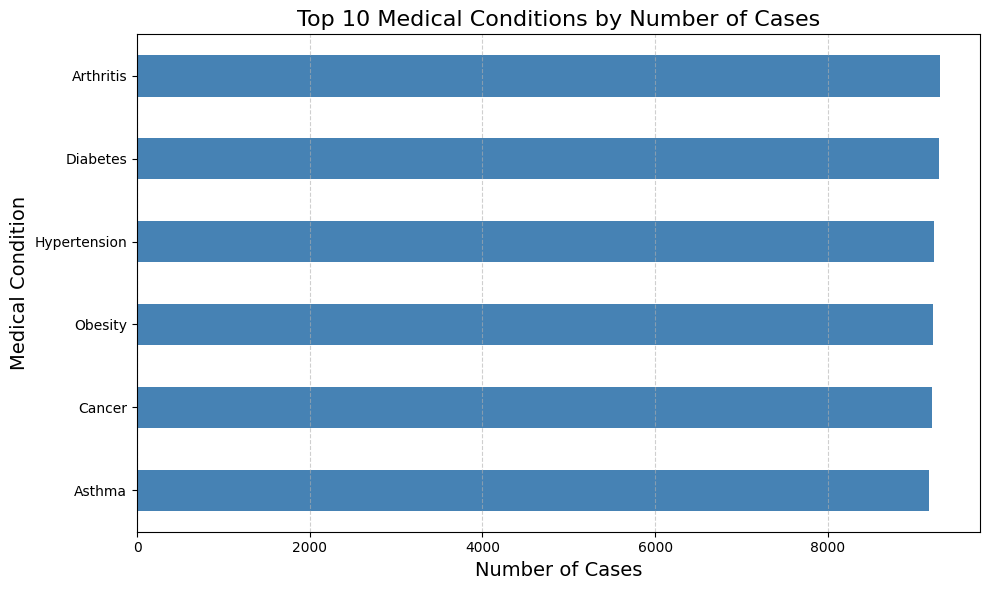

In [ ]:
plt.figure(figsize=(10, 6))
condition_summary["count"].sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 10 Medical Conditions by Number of Cases", fontsize=16)
plt.xlabel("Number of Cases", fontsize=14)
plt.ylabel("Medical Condition", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

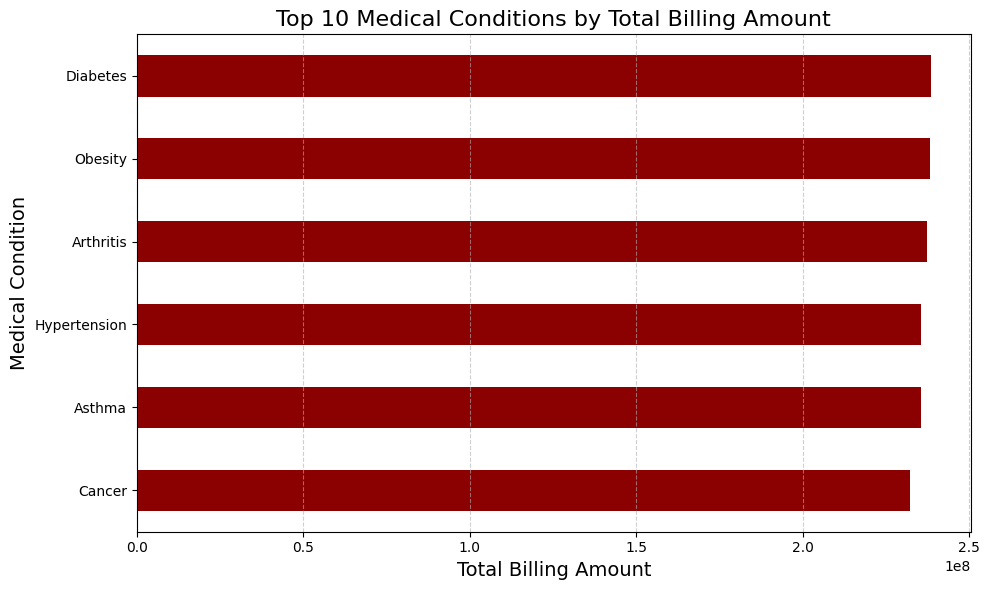

In [ ]:
plt.figure(figsize=(10, 6))
condition_summary["sum"].sort_values().plot(kind='barh', color='darkred')
plt.title("Top 10 Medical Conditions by Total Billing Amount", fontsize=16)
plt.xlabel("Total Billing Amount", fontsize=14)
plt.ylabel("Medical Condition", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Analysis:**.
- Some diseases such as **asthma**, **hypertension** and **diabetes** appear with high frequency and also generate a relevant economic impact.
- Other less frequent conditions may have a high unit cost, but their cumulative effect is minor in comparison.
- The company faces a double pressure: frequent diseases with medium cost and rare diseases with high costs.

## 8.4 What are the variations in medical costs according to the hospital providing the service and how could HealthWise use this data to refine its business operations?

In [ ]:
hospital_summary = df.groupby("hospital")["billing_amount"].agg(["count", "mean", "median", "std", "sum"]).sort_values(by="mean", ascending=False).head(10)
print(hospital_summary)

                                count          mean        median  std  \
hospital                                                                 
Hernandez-Morton                    2  52373.032374  52373.032374  0.0   
Walker-Garcia                       2  52170.036854  52170.036854  0.0   
Ruiz-Anthony                        1  52154.237722  52154.237722  NaN   
George-Gonzalez                     1  52102.240889  52102.240889  NaN   
Rocha-Carter                        1  52092.669896  52092.669896  NaN   
Briggs Martinez, Walker and         1  52024.726443  52024.726443  NaN   
Harrington, Small Stephens and      2  51975.968135  51975.968135  0.0   
Clark-Espinoza                      1  51848.201597  51848.201597  NaN   
James, Miller Pierce and            1  51722.122739  51722.122739  NaN   
Lester-Park                         1  51661.012033  51661.012033  NaN   

                                          sum  
hospital                                       
Hernandez-Morto

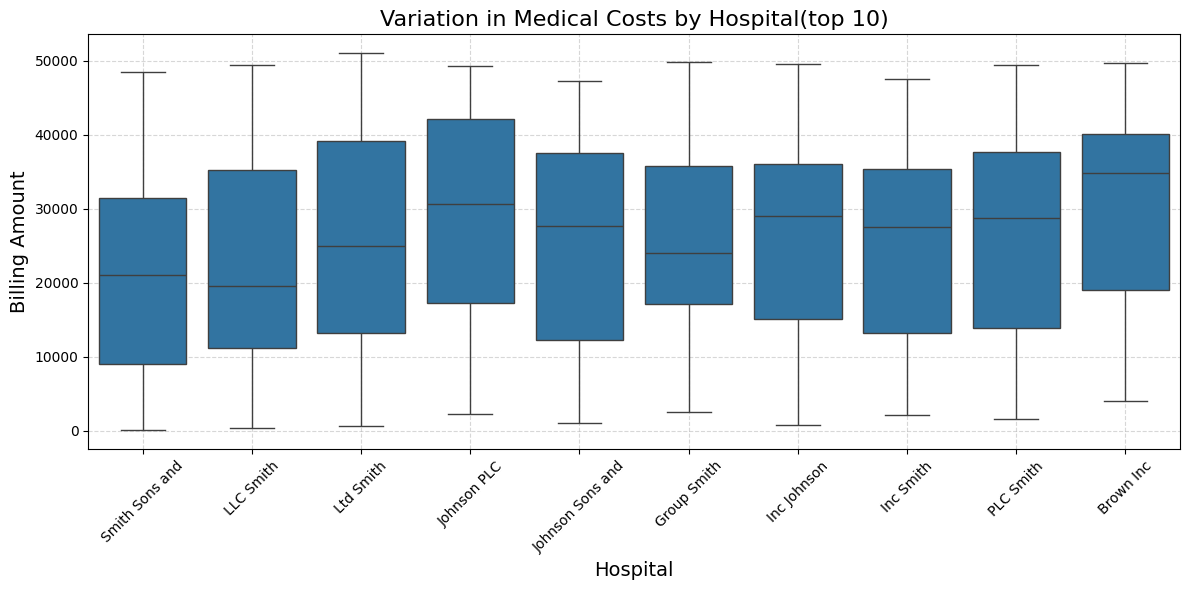

In [ ]:
plt.figure(figsize=(12, 6))
top_hospitals = df["hospital"].value_counts().head(10).index
df_filtered = df[df["hospital"].isin(top_hospitals)]
sns.boxplot(x="hospital", y="billing_amount", data=df_filtered)
plt.title("Variation in Medical Costs by Hospital(top 10)", fontsize=16)
plt.xlabel("Hospital", fontsize=14)
plt.ylabel("Billing Amount", fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Analysis:**.
- The hospitals are quite different from each other in terms of their average cost and data dispersion.
- Renegotiate and review hospital agreements with high average costs.
- Develop clinical and financial performance measures to compare institutions.
- Give top priority to collaborations with centers that show a high correspondence between quality and cost.

## 8.5 Which medical conditions have the greatest variability in costs and how can HealthWise standardize their management?

Calculating the standard deviation of costs by medical pathology will allow us to identify those diseases that present greater variability or dispersion in billing amounts. This is useful for recognizing conditions that do not have stable cost patterns, which may indicate lack of control or diverse treatments.

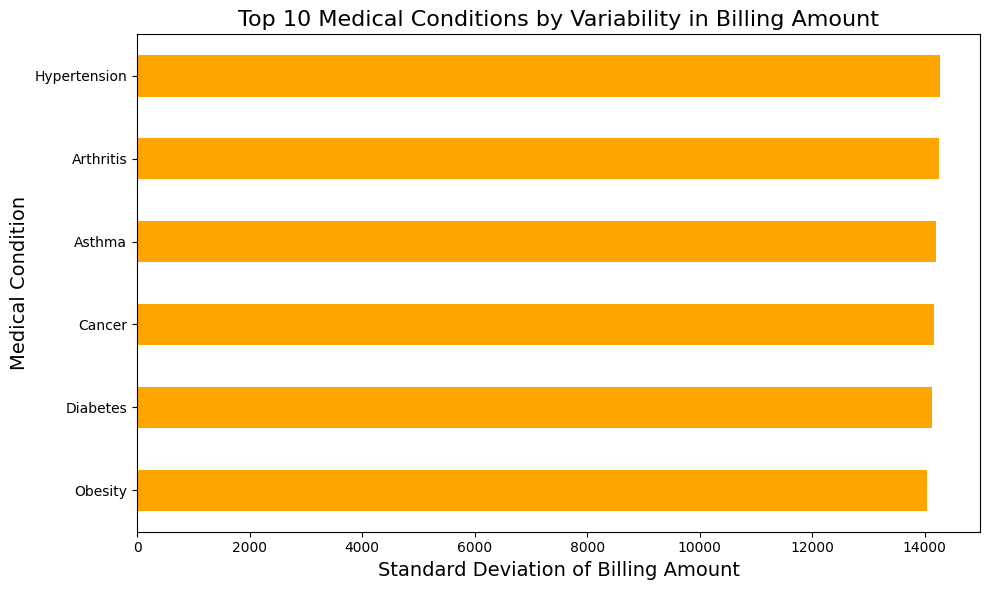

In [ ]:
variability_df = df.groupby("medical_condition")["billing_amount"].agg(["count", "mean", "std"]).sort_values(by="std", ascending=False).head(10)
plt.figure(figsize=(10, 6))
variability_df["std"].sort_values().plot(kind='barh', color='orange')
plt.title("Top 10 Medical Conditions by Variability in Billing Amount", fontsize=16)
plt.xlabel("Standard Deviation of Billing Amount", fontsize=14)
plt.ylabel("Medical Condition", fontsize=14)
plt.tight_layout()
plt.show()


**Analisys:**
- HealthWise may be suffering from **lack of standardization** or variability in clinical complexity for these conditions.
- Highly variable diseases require quality control in care and financial management.

**Recommendations:**

- Investigate causes of high variability: variability in treatment, clinical practices, billing errors.
- Standardize procedures for highly expensive conditions.
- Conduct clinical and administrative audits for conditions with high standard deviation.


## 8.6 Are there significant differences in costs between men and women when treating the same medical conditions?


gender                   Female          Male        diff
medical_condition                                        
Asthma             25448.276205  25920.574256  472.298051
Arthritis          25373.060513  25685.303062  312.242549
Cancer             25325.476612  25104.912406  220.564206
Diabetes           25588.704313  25800.256508  211.552195
Obesity            25913.002172  25807.504225  105.497947
Hypertension       25512.621858  25599.359478   86.737621


<Figure size 1000x600 with 0 Axes>

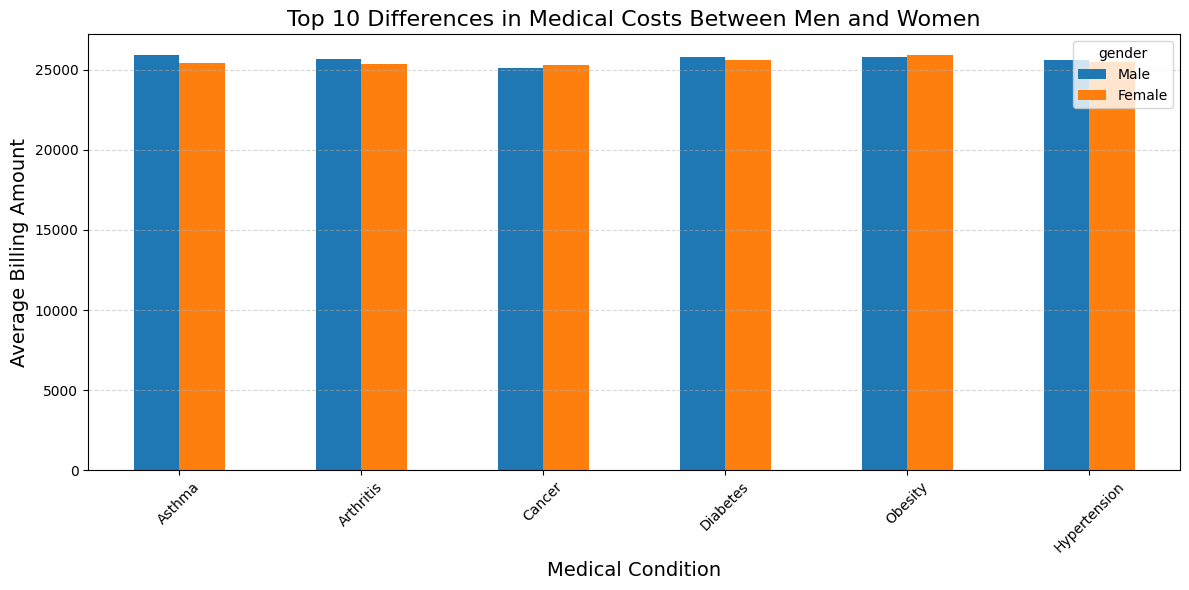

In [ ]:
gender_condition_cost = df.groupby(["medical_condition", "gender"])["billing_amount"].mean().unstack()
gender_condition_cost = gender_condition_cost.dropna()
gender_condition_cost["diff"] = abs(gender_condition_cost["Male"] - gender_condition_cost["Female"])
top_diff = gender_condition_cost.sort_values(by="diff", ascending=False).head(10)
print(top_diff)
plt.figure(figsize=(10, 6))
top_diff[["Male", "Female"]].plot(kind='bar', figsize=(12, 6))
plt.title("Top 10 Differences in Medical Costs Between Men and Women", fontsize=16)
plt.xlabel("Medical Condition", fontsize=14)
plt.ylabel("Average Billing Amount", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Analysis:**

- There were large differences in billed costs between men and women for certain medical conditions.
- There were large differences in billed costs between men and women for certain medical conditions.
- These could be due to clinical, social or administrative factors, for example, the treatment employed or the duration of treatment.

**Conclusion:**
- HealthWise could be incurring gender-disproportionate costs for the same condition, which should be analyzed thoroughly.
- Inequity may affect budget and equity of care.

**Recommendations:**
- Investigate clinical and operational reasons behind the disparities observed.
- Review whether protocols are equitable regarding treatment, follow-up and cost.
- Adopt review policies to guarantee that services delivered do not vary unreasonably by gender.

**Cross-analysis with Question 1**
- Question 1 had shown variations in cost by gender and age in broad terms.
- This Question 5 follows on from that finding, discovering that even **treating the same disease**, there is variation in cost by gender.
- This suggests that inequity determinants can happen not only at the population level, but even within the direct management of medical conditions.
- The crossover of results supports the hypothesis that there are opportunities for optimizing costs and improving clinical equity from a gender perspective.



---
# 9. Conclusion
The exploratory analysis conducted identified major areas of HealthWise's medical cost management. Through a systematic and rigorous approach, strategic questions were resolved that reveal operational behaviors, differences, and opportunities for clinical and financial improvement.

**Major findings**
- There are **statistically significant variations in medical costs** by age, gender and clinical status.
- Some pathologies have **high variability of costs**, which indicates a non-standardization of treatments or protocols.
- Gender differentials were recognized even within the identical illnesses, which may affect equity and institutional spending.
- The complementarity of general (Question 1) and specific (Questions 4 and 5) analysis allowed us to develop an integrative and actionable view.

**Why was this analysis performed?**

HealthWise is in a state of financial instability and needs improved understanding of how costs are being generated for it to make informed decisions based on evidence. That need is addressed directly by this EDA.

**Recomended next steps:**
1. Conduct thorough audits of conditions with most variability and gender imbalance.
2. Standardize treatment protocols, especially for common conditions like hypertension and asthma.
3. Develop interactive dashboards based on these findings for ongoing monitoring.
4. Develop cost control strategies based on the most costly segments delineated.

This analysis is the beginning of informed, fact-driven cost management. Its continuation and periodic revision will be critical to improving HealthWise's fiscal sustainability and quality of care.



---
 # 10. References

 - McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. In Proceedings of the 9th Python in Science Conference, pp. 51–56.
 -Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, pp. 2825–2830.
 - Kaggle. (2024). *Healthcare Dataset*. https://www.kaggle.com/
